In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/sales_data.csv")

In [7]:
df.head()

,Order ID,Order Date,Product,Category,City,Quantity,Unit Price,Total Sales
0,1029,2025-01-01,Backpack,Bags & Luggage,Pune,1,1784.86,1784.86
1,1094,2025-01-01,Formal Shoes,Footwear,Lucknow,1,2763.45,2763.45
2,1026,2025-01-02,Running Shoes,Footwear,Jaipur,3,2366.88,7100.64
3,1192,2025-01-02,Formal Shoes,Footwear,Lucknow,3,2923.24,8769.72
4,1333,2025-01-03,USB-C Charger,Electronics,Bengaluru,1,761.02,761.02


In [9]:
df.shape

(600, 8)

In [10]:
df.columns

Index(['Order ID', 'Order Date', 'Product', 'Category', 'City', 'Quantity',
       'Unit Price', 'Total Sales'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order ID     600 non-null    int64  
 1   Order Date   600 non-null    str    
 2   Product      600 non-null    str    
 3   Category     600 non-null    str    
 4   City         600 non-null    str    
 5   Quantity     600 non-null    int64  
 6   Unit Price   600 non-null    float64
 7   Total Sales  600 non-null    float64
dtypes: float64(2), int64(2), str(4)
memory usage: 37.6 KB


In [12]:
df.describe()

,Order ID,Quantity,Unit Price,Total Sales
count,600.000000,600.000000,600.000000,600.000000
mean,1299.500000,2.065000,1281.247667,2642.900350
std,173.349358,1.230161,862.548572,2603.034839
min,1000.000000,1.000000,237.640000,237.850000
25%,1149.750000,1.000000,612.852500,1000.715000
50%,1299.500000,2.000000,1064.320000,1752.040000
75%,1449.250000,3.000000,1682.447500,3443.047500
max,1599.000000,5.000000,3770.240000,14889.450000


In [13]:
df.isnull().sum()

Order ID       0
Order Date     0
Product        0
Category       0
City           0
Quantity       0
Unit Price     0
Total Sales    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.tail()

,Order ID,Order Date,Product,Category,City,Quantity,Unit Price,Total Sales
595,1166,2025-12-28,Formal Shoes,Footwear,Surat,2,2914.85,5829.70
596,1136,2025-12-29,Laptop Stand,Electronics,Surat,3,1206.93,3620.79
597,1594,2025-12-30,Backpack,Bags & Luggage,Bengaluru,1,1857.04,1857.04
598,1256,2025-12-31,Yoga Mat,Sports & Fitness,Chennai,2,698.66,1397.32
599,1326,2025-12-31,Notebook Pack (5pc),Stationery,Bengaluru,1,264.10,264.10


In [17]:
df.columns

Index(['Order ID', 'Order Date', 'Product', 'Category', 'City', 'Quantity',
       'Unit Price', 'Total Sales'],
      dtype='str')

In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order ID     600 non-null    int64         
 1   Order Date   600 non-null    datetime64[us]
 2   Product      600 non-null    str           
 3   Category     600 non-null    str           
 4   City         600 non-null    str           
 5   Quantity     600 non-null    int64         
 6   Unit Price   600 non-null    float64       
 7   Total Sales  600 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 37.6 KB


In [20]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [21]:
df.head()

,Order ID,Order Date,Product,Category,City,Quantity,Unit Price,Total Sales,Month
0,1029,2025-01-01,Backpack,Bags & Luggage,Pune,1,1784.86,1784.86,2025-01
1,1094,2025-01-01,Formal Shoes,Footwear,Lucknow,1,2763.45,2763.45,2025-01
2,1026,2025-01-02,Running Shoes,Footwear,Jaipur,3,2366.88,7100.64,2025-01
3,1192,2025-01-02,Formal Shoes,Footwear,Lucknow,3,2923.24,8769.72,2025-01
4,1333,2025-01-03,USB-C Charger,Electronics,Bengaluru,1,761.02,761.02,2025-01


In [22]:
monthly_sales = df.groupby("Month")["Total Sales"].sum()

In [23]:
monthly_sales

Month
2025-01    108067.19
2025-02    113034.74
2025-03    152235.15
2025-04     78351.83
2025-05    132976.61
2025-06    158377.33
2025-07    110774.53
2025-08    179275.52
2025-09     99079.67
2025-10    133311.29
2025-11    157460.53
2025-12    162795.82
Freq: M, Name: Total Sales, dtype: float64

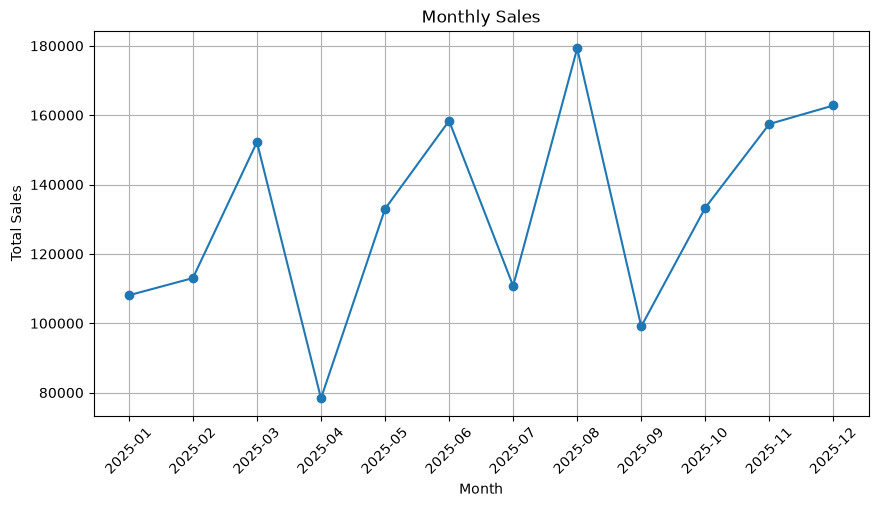

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [25]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [27]:
df.groupby("Category")["Total Sales"].sum()

Category
Apparel                   191493.31
Bags & Luggage            109223.49
Beauty & Personal Care     90161.22
Books                      50550.85
Electronics               408873.18
Footwear                  388332.23
Home & Kitchen            199237.86
Sports & Fitness          128740.01
Stationery                 19128.06
Name: Total Sales, dtype: float64

In [28]:
category_sales = df.groupby("Category")["Total Sales"].sum()

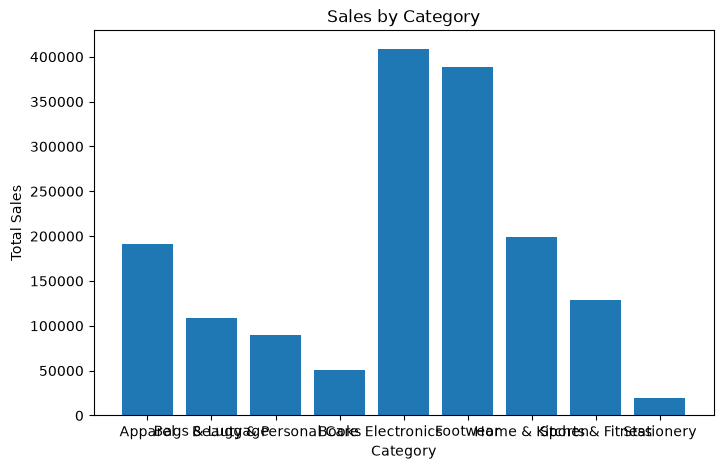

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

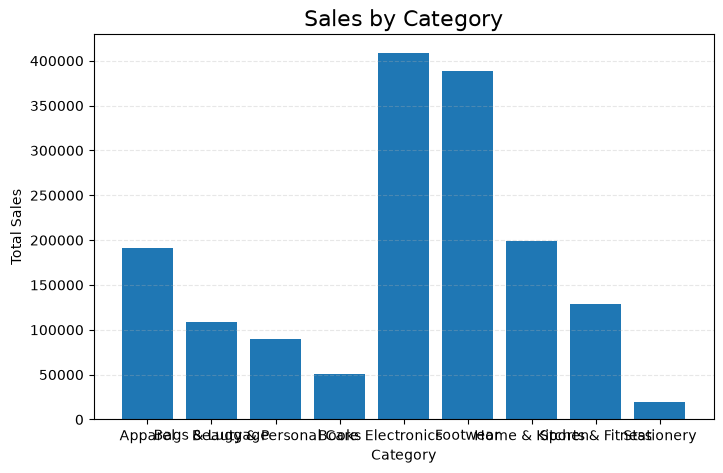

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Sales by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [31]:
total_revenue = df["Total Sales"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1585740.21


In [32]:
product_sales = df.groupby("Product")["Total Sales"].sum()

top_product = product_sales.idxmax()
top_sales = product_sales.max()

print("Top Product:", top_product)
print(f"Total Sales: ₹{top_sales:,.2f}")

Top Product: Formal Shoes
Total Sales: ₹254,768.70


In [33]:
category_sales = df.groupby("Category")["Total Sales"].sum()

most_sales_category = category_sales.idxmax()
most_sales = category_sales.max()

print("Category with highest sales:", most_sales_category)
print(f"Total Sales: ₹{most_sales:,.2f}")

Category with highest sales: Electronics
Total Sales: ₹408,873.18


In [34]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print(f"Total Sales: ₹{highest_sales:,.2f}")

Highest Sales Month: 2025-08
Total Sales: ₹179,275.52


In [35]:
city_sales = df.groupby("City")["Total Sales"].sum()

In [36]:
highest_city = city_sales.idxmax()
highest_revenue = city_sales.max()

print("Highest Revenue City:", highest_city)
print(f"Revenue: ₹{highest_revenue:,.2f}")

Highest Revenue City: Delhi
Revenue: ₹214,188.31


In [37]:
total_revenue = df["Total Sales"].sum()
total_orders = df["Order ID"].nunique()

average_order_value = total_revenue / total_orders

print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹2,642.90


In [38]:
poor_products = product_sales.sort_values(ascending=True)

print(poor_products)

Product
Notebook Pack (5pc)      19128.06
Men's Cotton T-Shirt     20338.69
Face Wash                25754.21
LED Desk Lamp            30245.71
Yoga Mat                 30765.64
Wireless Mouse           31448.98
USB-C Charger            47369.33
Storybook Set (Kids)     50550.85
Women's Kurti            51535.21
Non-stick Pan            62036.85
Hair Dryer               64407.01
Bluetooth Headphones     79556.36
Laptop Stand             96719.44
Dumbbell Set (10kg)      97974.37
Electric Kettle         106955.30
Backpack                109223.49
Denim Jeans             119619.41
Running Shoes           133563.53
Smartwatch              153779.07
Formal Shoes            254768.70
Name: Total Sales, dtype: float64


In [39]:
bottom_5_products = product_sales.sort_values(ascending=True).head(5)

print(bottom_5_products)

Product
Notebook Pack (5pc)     19128.06
Men's Cotton T-Shirt    20338.69
Face Wash               25754.21
LED Desk Lamp           30245.71
Yoga Mat                30765.64
Name: Total Sales, dtype: float64


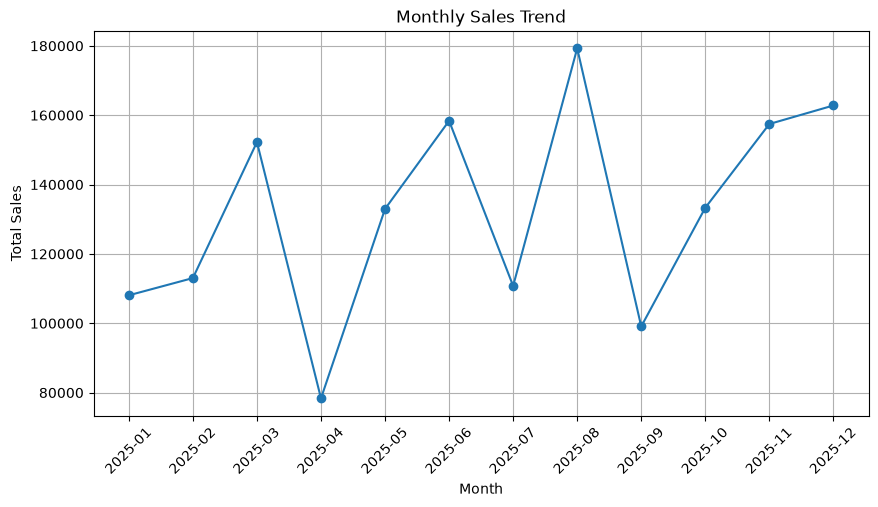

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [41]:
category_percentage = (category_sales / df["Total Sales"].sum()) * 100

print(category_percentage)

Category
Apparel                   12.075957
Bags & Luggage             6.887855
Beauty & Personal Care     5.685750
Books                      3.187839
Electronics               25.784374
Footwear                  24.489020
Home & Kitchen            12.564344
Sports & Fitness           8.118607
Stationery                 1.206254
Name: Total Sales, dtype: float64


In [42]:
category_percentage = category_percentage.sort_values(ascending=False)

print(category_percentage)

Category
Electronics               25.784374
Footwear                  24.489020
Home & Kitchen            12.564344
Apparel                   12.075957
Sports & Fitness           8.118607
Bags & Luggage             6.887855
Beauty & Personal Care     5.685750
Books                      3.187839
Stationery                 1.206254
Name: Total Sales, dtype: float64
